# IMPORTS

In [1]:
import os
import gc
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder


In [3]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

In [4]:
# GPU setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla T4
GPU Memory: 15.83 GB



# CONFIGURATION

In [5]:
class Config:
    # Paths
    DATA_DIR = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'
    TRAIN_DIR = f'{DATA_DIR}/train'
    TEST_DIR = f'{DATA_DIR}/test'
    
    # Training params
    BATCH_SIZE = 32
    IMAGE_SIZE = 224  # EfficientNet standard
    NUM_EPOCHS = 15
    MAX_LR = 0.001
    WEIGHT_DECAY = 1e-4
    GRAD_CLIP = 0.1
    
    # Data split
    TRAIN_VAL_SPLIT = 0.85  # 85% train, 15% val
    
    # Workers
    NUM_WORKERS = 2
    # Checkpoint
    CHECKPOINT_PATH = 'efficientnet_b4_deepfake.pth'
    BEST_MODEL_PATH = 'best_efficientnet_b4.pth'
    
    # Random seed
    SEED = 42

config = Config()

In [6]:
# Set seed
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)

print("\nDataset Structure:")
print(f"Train dir: {config.TRAIN_DIR}")
print(f"Test dir: {config.TEST_DIR}")



Dataset Structure:
Train dir: /kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train
Test dir: /kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test


In [7]:
# Check dataset
for split_name, path in [("Train", config.TRAIN_DIR), ("Test", config.TEST_DIR)]:
    print(f"\n{split_name}:")
    for class_name in sorted(os.listdir(path)):
        class_path = os.path.join(path, class_name)
        if os.path.isdir(class_path):
            num_files = len(os.listdir(class_path))
            print(f"  {class_name}: {num_files:,} images")


Train:
  fake: 50,000 images
  real: 50,000 images

Test:
  fake: 10,000 images
  real: 10,000 images


# DATA TRANSFORMS

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# DATASET & DATALOADER

In [9]:
print("\n" + "="*60)
print("LOADING DATASETS")
print("="*60)

# Load datasets
train_dataset = ImageFolder(root=config.TRAIN_DIR, transform=train_transforms)
test_dataset = ImageFolder(root=config.TEST_DIR, transform=test_transforms)

print(f"\n✓ Total train images: {len(train_dataset):,}")
print(f"✓ Total test images: {len(test_dataset):,}")
print(f"✓ Classes: {train_dataset.classes}")
print(f"✓ Class to index: {train_dataset.class_to_idx}")


LOADING DATASETS

✓ Total train images: 100,000
✓ Total test images: 20,000
✓ Classes: ['fake', 'real']
✓ Class to index: {'fake': 0, 'real': 1}


In [10]:
# Train/Val split
train_size = int(config.TRAIN_VAL_SPLIT * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = torch.utils.data.random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(config.SEED)
)

print(f"\nData Split:")
print(f"  Train: {len(train_subset):,} ({len(train_subset)/len(train_dataset)*100:.1f}%)")
print(f"  Val:   {len(val_subset):,} ({len(val_subset)/len(train_dataset)*100:.1f}%)")
print(f"  Test:  {len(test_dataset):,}")


Data Split:
  Train: 85,000 (85.0%)
  Val:   15,000 (15.0%)
  Test:  20,000


In [11]:
# DataLoaders
train_loader = DataLoader(
    train_subset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=config.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

print(f"\n✓ Train batches: {len(train_loader)}")
print(f"✓ Val batches: {len(val_loader)}")
print(f"✓ Test batches: {len(test_loader)}")


✓ Train batches: 2657
✓ Val batches: 235
✓ Test batches: 313


# MODEL - EfficientNet-B4 with Transfer Learning

In [12]:
print("\n" + "="*60)
print("BUILDING MODEL")
print("="*60)

class DeepfakeDetector(nn.Module):
    def __init__(self, pretrained=True):
        super(DeepfakeDetector, self).__init__()
        
        # Load pretrained EfficientNet-B4
        self.backbone = models.efficientnet_b4(pretrained=pretrained)
        
        # Freeze early layers (transfer learning)
        for param in self.backbone.features[:-3].parameters():
            param.requires_grad = False
        
        # Replace classifier
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(p=0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.backbone(x)

model = DeepfakeDetector(pretrained=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Model: EfficientNet-B4")
print(f"✓ Device: {device}")
print(f"✓ Total parameters: {total_params:,}")
print(f"✓ Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")


BUILDING MODEL


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



✓ Model: EfficientNet-B4
✓ Device: cuda
✓ Total parameters: 18,599,753
✓ Trainable parameters: 14,963,769 (80.5%)


# LOSS, OPTIMIZER, SCHEDULER

In [13]:
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.MAX_LR,
    weight_decay=config.WEIGHT_DECAY
)

In [14]:
# OneCycleLR scheduler 
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config.MAX_LR,
    epochs=config.NUM_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,  # 30% warmup
    anneal_strategy='cos'
)
print(f"\n✓ Loss: Binary Cross Entropy")
print(f"✓ Optimizer: AdamW (lr={config.MAX_LR})")
print(f"✓ Scheduler: OneCycleLR")


✓ Loss: Binary Cross Entropy
✓ Optimizer: AdamW (lr=0.001)
✓ Scheduler: OneCycleLR


# METRICS CALCULATION

In [15]:
def calculate_metrics(outputs, labels):
    """Calculate accuracy, precision, recall, F1"""
    outputs = outputs.view(-1).cpu().numpy()
    labels = labels.view(-1).cpu().numpy()
    
    preds = (outputs >= 0.5).astype(int)
    
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

# TRAINING & VALIDATION FUNCTIONS

In [16]:
def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_outputs = []
    all_labels = []
    
    progress_bar = tqdm(loader, desc="Training", leave=False)
    
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        # Forward
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward
        loss.backward()
        
        # Gradient clipping (from Rajat - good practice!)
        if config.GRAD_CLIP:
            nn.utils.clip_grad_norm_(model.parameters(), config.GRAD_CLIP)
        
        optimizer.step()
        scheduler.step()
        
        # Stats
        running_loss += loss.item() * images.size(0)
        all_outputs.append(outputs.detach().cpu())
        all_labels.append(labels.detach().cpu())
        
        # Update progress
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'lr': f'{scheduler.get_last_lr()[0]:.6f}'
        })
    
    # Calculate metrics
    epoch_loss = running_loss / len(loader.dataset)
    all_outputs = torch.cat(all_outputs)
    all_labels = torch.cat(all_labels)
    metrics = calculate_metrics(all_outputs, all_labels)
    
    return epoch_loss, metrics, scheduler.get_last_lr()[0]

In [17]:
@torch.no_grad()
def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    all_outputs = []
    all_labels = []
    
    progress_bar = tqdm(loader, desc="Validation", leave=False)
    
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        all_outputs.append(outputs.cpu())
        all_labels.append(labels.cpu())
    
    epoch_loss = running_loss / len(loader.dataset)
    all_outputs = torch.cat(all_outputs)
    all_labels = torch.cat(all_labels)
    metrics = calculate_metrics(all_outputs, all_labels)
    
    return epoch_loss, metrics, all_outputs, all_labels

# CHECKPOINT MANAGEMENT

In [21]:
def save_checkpoint(epoch, model, optimizer, scheduler, history, filepath):
    """Save training checkpoint"""
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': history
    }, filepath)

def load_checkpoint(filepath, model, optimizer, scheduler):
    """Load training checkpoint"""
    if os.path.exists(filepath):
        checkpoint = torch.load(filepath, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        history = checkpoint['history']
        start_epoch = checkpoint['epoch'] + 1
        print(f"✓ Resuming from epoch {start_epoch}")
        return start_epoch, history
    return 0, []

# TRAINING LOOP

In [22]:
print("\n" + "="*60)
print("TRAINING START")
print("="*60)

# Try to load checkpoint
start_epoch, history = load_checkpoint(
    config.CHECKPOINT_PATH, model, optimizer, scheduler
)

best_val_acc = max([h['val_acc'] for h in history], default=0.0)

for epoch in range(start_epoch, config.NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch [{epoch+1}/{config.NUM_EPOCHS}]")
    print(f"{'='*60}")
    
    # Train
    train_loss, train_metrics, current_lr = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, device
    )
    
    # Validate
    val_loss, val_metrics, val_outputs, val_labels = validate_epoch(
        model, val_loader, criterion, device
    )
    # Store history
    epoch_result = {
        'epoch': epoch + 1,
        'lr': current_lr,
        'train_loss': train_loss,
        'train_acc': train_metrics['accuracy'],
        'train_precision': train_metrics['precision'],
        'train_recall': train_metrics['recall'],
        'train_f1': train_metrics['f1_score'],
        'val_loss': val_loss,
        'val_acc': val_metrics['accuracy'],
        'val_precision': val_metrics['precision'],
        'val_recall': val_metrics['recall'],
        'val_f1': val_metrics['f1_score']
    }
    history.append(epoch_result)
    # Print results
    print(f"\nTrain → Loss: {train_loss:.4f} | Acc: {train_metrics['accuracy']:.4f} | "
          f"Prec: {train_metrics['precision']:.4f} | Rec: {train_metrics['recall']:.4f} | "
          f"F1: {train_metrics['f1_score']:.4f}")
    print(f"Val   → Loss: {val_loss:.4f} | Acc: {val_metrics['accuracy']:.4f} | "
          f"Prec: {val_metrics['precision']:.4f} | Rec: {val_metrics['recall']:.4f} | "
          f"F1: {val_metrics['f1_score']:.4f}")
    print(f"LR: {current_lr:.6f}")
    
    # Save checkpoint
    save_checkpoint(epoch, model, optimizer, scheduler, history, config.CHECKPOINT_PATH)
    
    # Save best model
    if val_metrics['accuracy'] > best_val_acc:
        best_val_acc = val_metrics['accuracy']
        torch.save(model.state_dict(), config.BEST_MODEL_PATH)
        print(f"✓ New best model saved! (Val Acc: {best_val_acc:.4f})")
    
    # Clear GPU cache
    gc.collect()
    torch.cuda.empty_cache()
print("\n" + "="*60)
print(f"TRAINING COMPLETE - Best Val Acc: {best_val_acc:.4f}")
print("="*60)
    


TRAINING START
✓ Resuming from epoch 5

Epoch [6/15]


Training:   0%|          | 0/2657 [00:00<?, ?it/s]

Validation:   0%|          | 0/235 [00:00<?, ?it/s]


Train → Loss: 0.0974 | Acc: 0.9683 | Prec: 0.9685 | Rec: 0.9681 | F1: 0.9683
Val   → Loss: 0.0595 | Acc: 0.9805 | Prec: 0.9707 | Rec: 0.9908 | F1: 0.9807
LR: 0.000950
✓ New best model saved! (Val Acc: 0.9805)

Epoch [7/15]


Training:   0%|          | 0/2657 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/235 [00:00<?, ?it/s]


Train → Loss: 0.0236 | Acc: 0.9937 | Prec: 0.9935 | Rec: 0.9939 | F1: 0.9937
Val   → Loss: 0.0323 | Acc: 0.9901 | Prec: 0.9944 | Rec: 0.9859 | F1: 0.9901
LR: 0.000022

Epoch [15/15]


Training:   0%|          | 0/2657 [00:00<?, ?it/s]

Validation:   0%|          | 0/235 [00:00<?, ?it/s]


Train → Loss: 0.0199 | Acc: 0.9945 | Prec: 0.9941 | Rec: 0.9949 | F1: 0.9945
Val   → Loss: 0.0325 | Acc: 0.9916 | Prec: 0.9964 | Rec: 0.9868 | F1: 0.9916
LR: 0.000000
✓ New best model saved! (Val Acc: 0.9916)

TRAINING COMPLETE - Best Val Acc: 0.9916


# VISUALIZATION


Creating training plots...


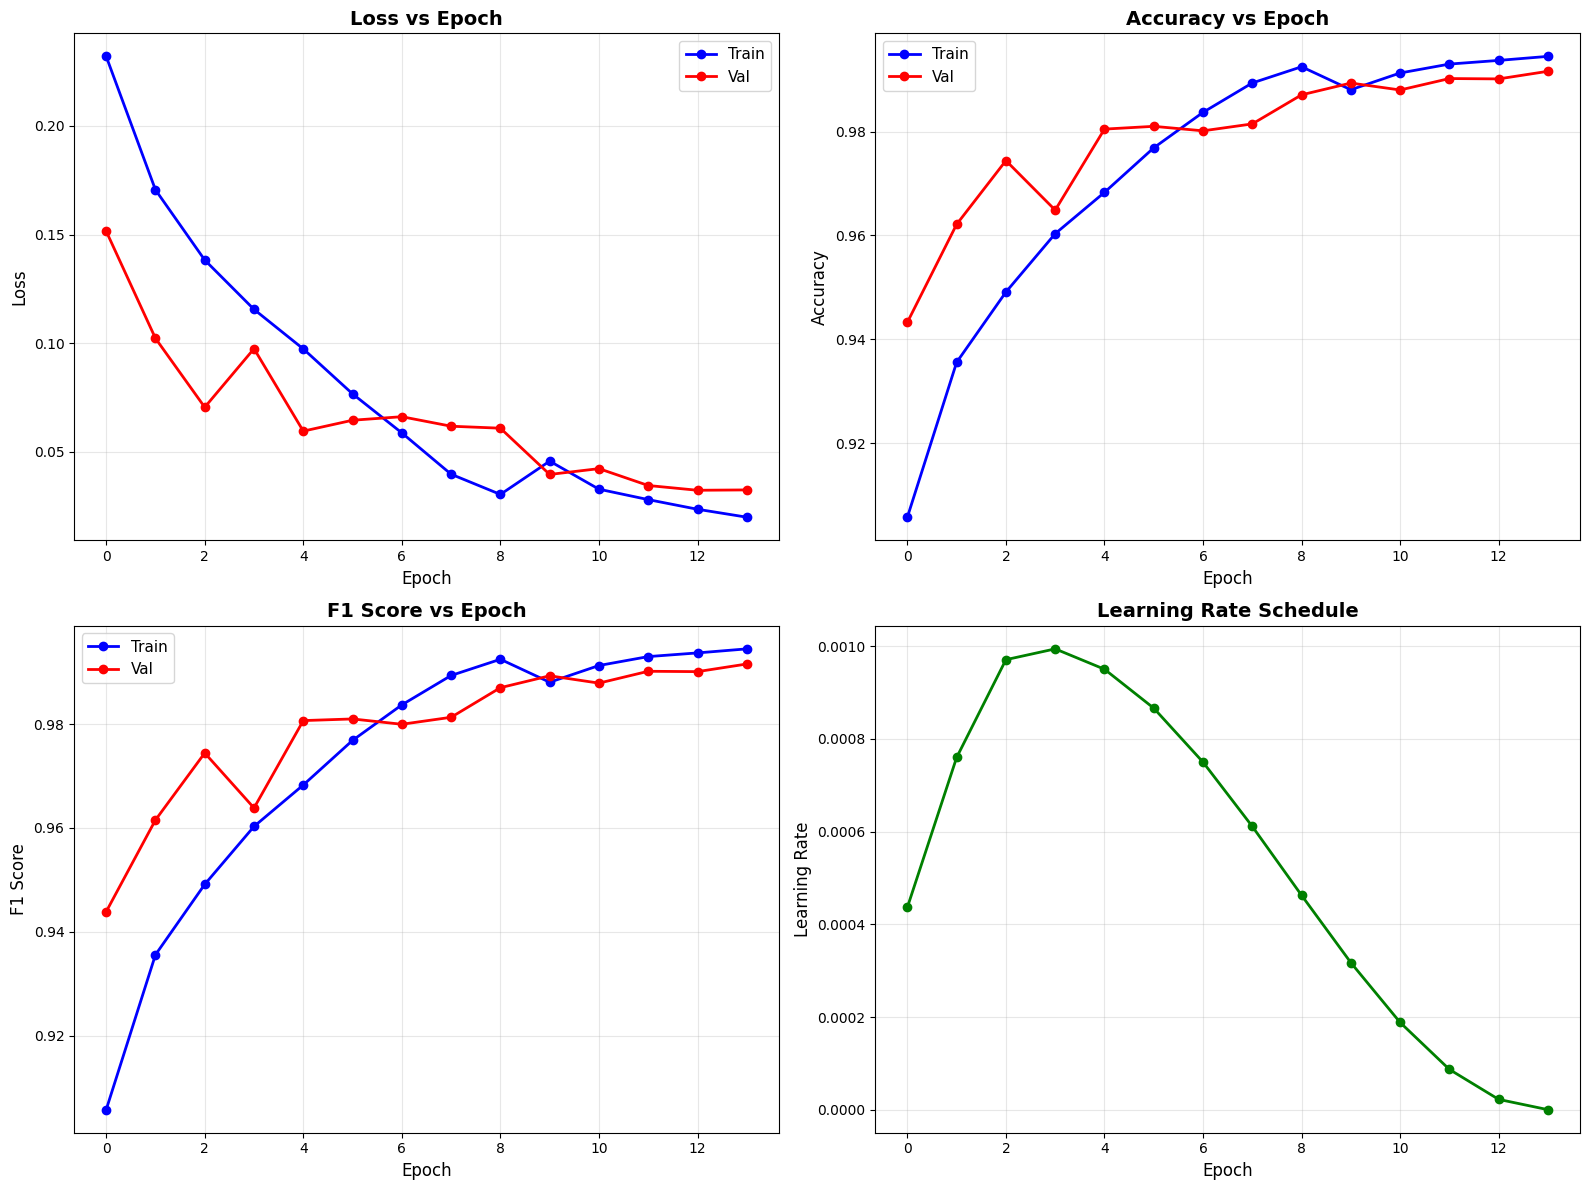

In [23]:
print("\nCreating training plots...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss
axes[0, 0].plot([h['train_loss'] for h in history[1:]], 'b-o', label='Train', linewidth=2, markersize=6)
axes[0, 0].plot([h['val_loss'] for h in history[1:]], 'r-o', label='Val', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Loss vs Epoch', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot([h['train_acc'] for h in history[1:]], 'b-o', label='Train', linewidth=2, markersize=6)
axes[0, 1].plot([h['val_acc'] for h in history[1:]], 'r-o', label='Val', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Accuracy vs Epoch', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[1, 0].plot([h['train_f1'] for h in history[1:]], 'b-o', label='Train', linewidth=2, markersize=6)
axes[1, 0].plot([h['val_f1'] for h in history[1:]], 'r-o', label='Val', linewidth=2, markersize=6)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('F1 Score', fontsize=12)
axes[1, 0].set_title('F1 Score vs Epoch', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot([h['lr'] for h in history[1:]], 'g-o', linewidth=2, markersize=6)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()


# TEST EVALUATION

In [24]:
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

# Load best model
model.load_state_dict(torch.load(config.BEST_MODEL_PATH))
print("✓ Loaded best model")

test_loss, test_metrics, test_outputs, test_labels = validate_epoch(
    model, test_loader, criterion, device
)

print(f"\n Test Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  Recall: {test_metrics['recall']:.4f}")
print(f"  F1 Score: {test_metrics['f1_score']:.4f}")


TEST SET EVALUATION
✓ Loaded best model


Validation:   0%|          | 0/313 [00:00<?, ?it/s]


 Test Results:
  Loss: 0.0080
  Accuracy: 0.9973 (99.73%)
  Precision: 0.9976
  Recall: 0.9970
  F1 Score: 0.9973


# DETAILED METRICS


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        fake     0.9970    0.9976    0.9973     10000
        real     0.9976    0.9970    0.9973     10000

    accuracy                         0.9973     20000
   macro avg     0.9973    0.9973    0.9973     20000
weighted avg     0.9973    0.9973    0.9973     20000



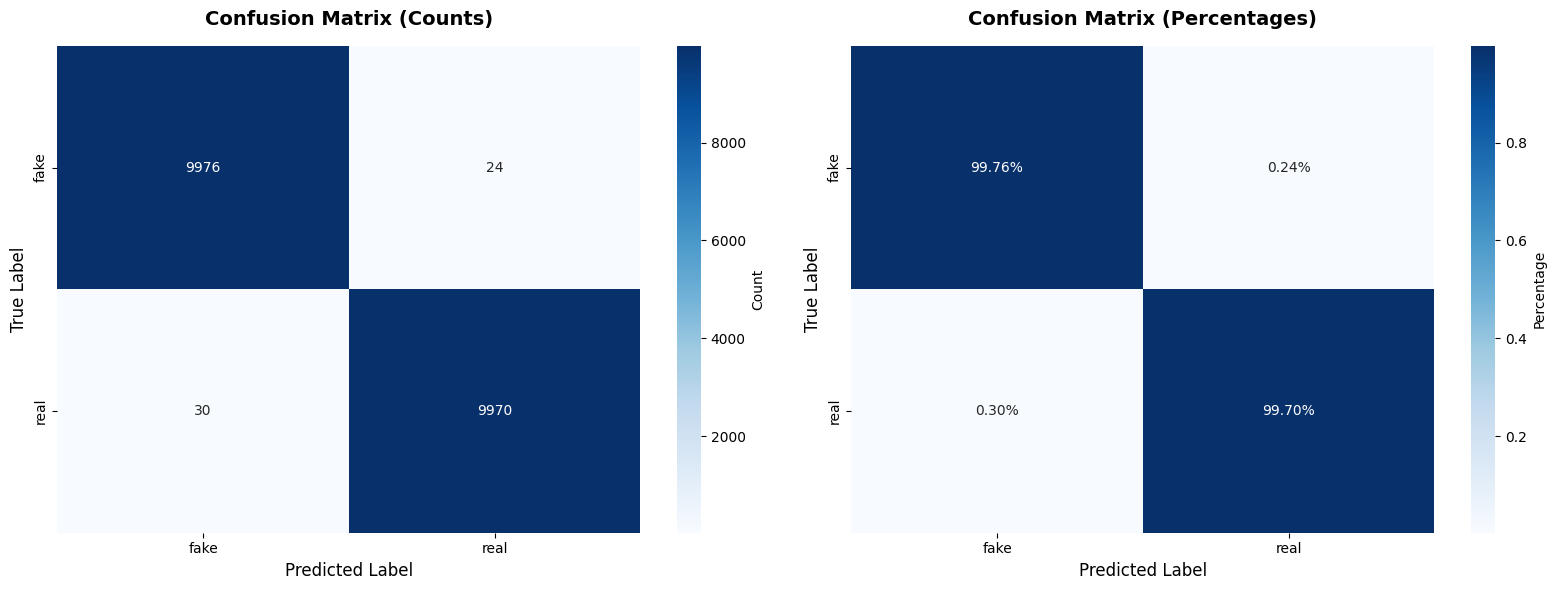

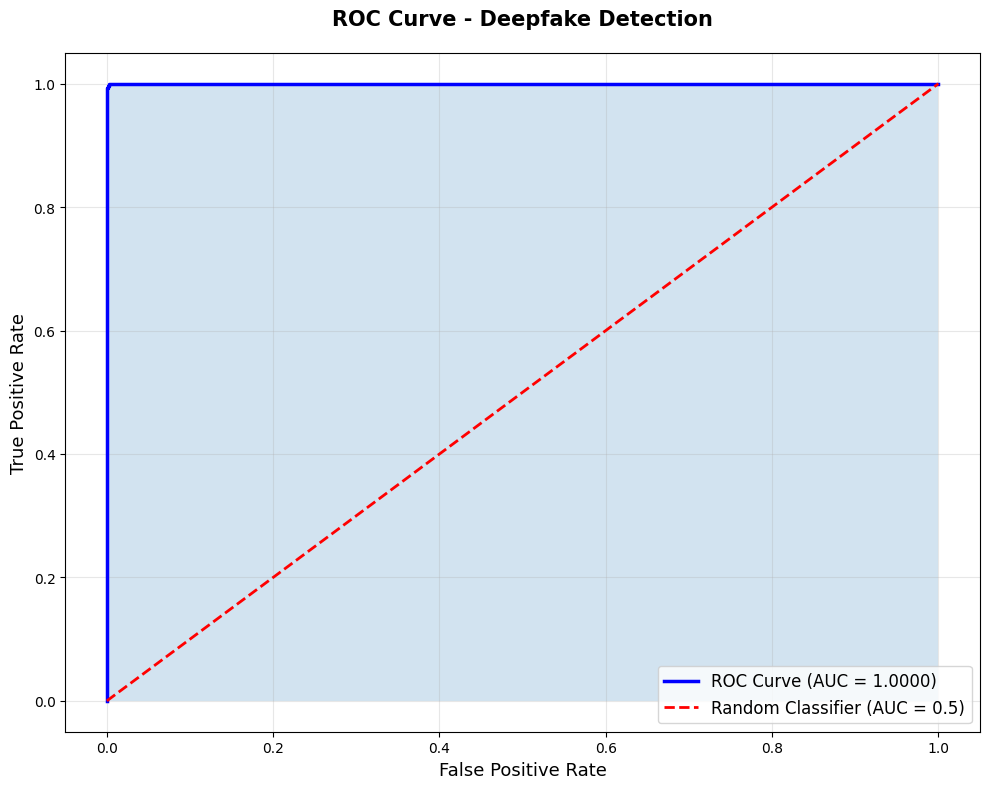


✓ AUC Score: 1.0000


In [25]:
test_outputs_np = test_outputs.numpy().flatten()
test_labels_np = test_labels.numpy().flatten().astype(int)
test_preds_np = (test_outputs_np >= 0.5).astype(int)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60 + "\n")

class_names = train_dataset.classes
print(classification_report(
    test_labels_np,
    test_preds_np,
    target_names=class_names,
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(test_labels_np, test_preds_np)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix - Counts
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    cbar_kws={'label': 'Count'}
)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Confusion Matrix - Percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    cbar_kws={'label': 'Percentage'}
)
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels_np, test_outputs_np)
auc_score = roc_auc_score(test_labels_np, test_outputs_np)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, 'b-', label=f'ROC Curve (AUC = {auc_score:.4f})', linewidth=2.5)
ax.plot([0, 1], [0, 1], 'r--', label='Random Classifier (AUC = 0.5)', linewidth=2)
ax.fill_between(fpr, tpr, alpha=0.2)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve - Deepfake Detection', fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ AUC Score: {auc_score:.4f}")

# SAVE RESULTS

In [27]:
results = {
    'model': 'EfficientNet-B4',
    'dataset': '140k Real and Fake Faces',
    'image_size': config.IMAGE_SIZE,
    'batch_size': config.BATCH_SIZE,
    'num_epochs': config.NUM_EPOCHS,
    'max_lr': config.MAX_LR,
    'weight_decay': config.WEIGHT_DECAY,
    'train_size': len(train_subset),
    'val_size': len(val_subset),
    'test_size': len(test_dataset),
    'best_val_acc': float(best_val_acc),
    'test_loss': float(test_loss),
    'test_accuracy': float(test_metrics['accuracy']),
    'test_precision': float(test_metrics['precision']),
    'test_recall': float(test_metrics['recall']),
    'test_f1': float(test_metrics['f1_score']),
    'auc_score': float(auc_score),
    'classes': class_names,
    'total_params': total_params,
    'trainable_params': trainable_params
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\n" + "="*60)
print("SAVED FILES")
print("="*60)
print("\n✓ best_efficientnet_b4.pth - Best model weights")
print("✓ efficientnet_b4_deepfake.pth - Last checkpoint")
print("✓ training_history.png - Training curves")
print("✓ confusion_matrix.png - Confusion matrices")
print("✓ roc_curve.png - ROC curve")
print("✓ results.json - All metrics")

print("\n" + "="*60)
print("🎉 TRAINING COMPLETE! 🎉")
print("="*60)
print(f"\n🏆 Final Results:")
print(f"  Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"  Test Accuracy: {test_metrics['accuracy']*100:.2f}%")
print(f"  AUC Score: {auc_score:.4f}")


SAVED FILES

✓ best_efficientnet_b4.pth - Best model weights
✓ efficientnet_b4_deepfake.pth - Last checkpoint
✓ training_history.png - Training curves
✓ confusion_matrix.png - Confusion matrices
✓ roc_curve.png - ROC curve
✓ results.json - All metrics

🎉 TRAINING COMPLETE! 🎉

🏆 Final Results:
  Best Validation Accuracy: 99.16%
  Test Accuracy: 99.73%
  AUC Score: 1.0000


In [1]:
print(train_dataset.class_to_idx)

NameError: name 'train_dataset' is not defined